# Evaluation du moteur de recherche

Dans ce notebook nous utilisons les annotations faites à la main pour calculé les métriques Precision de Rappel, et le score F1.
Nous testons aussi le temps moyen de réponse aux requêtes.

In [1]:
QUERIES: list[dict] = [
    {
        "id": 0,
        "query": "Quels sont les articles parus entre le 3 mars 2013 et le 4 mai 2013 évoquant les Etats-Unis ?",
        "relevant_ids": {72932},
    },
    {
        "id": 1,
        "query": "J’aimerais la liste des articles écrits après janvier 2014 et qui parlent d’informatique ou de télécommunications.",
        "relevant_ids": {75063, 75067, 75071, 75459, 75462, 75788, 75789, 75791, 75796, 76207, 76507, 76508, 76509},
    },
    {
        "id": 2,
        "query": "Je veux les articles qui parlent des systèmes embarqués et non pas la robotique.",
        "relevant_ids": {67796, 70165, 70168, 73187, 73879, 74751, 75071},
    },
    {
        "id": 3,
        "query": "Je veux voir les articles de la rubrique Focus et publiés entre 30/08/2011 et 29/09/2011.\"",
        "relevant_ids": {67553, 67554, 67555, 67794, 67795},
    },
    {
        "id": 4,
        "query": "Quels sont les articles traitant d’informatique ou de réseaux.",
        "relevant_ids": {67386, 67945, 68889, 69540, 70168, 70421, 70423, 70914, 71359, 71841, 73879, 74452, 74453, 74744, 74751, 75063, 75071, 75789, 75796, 76207, 76510},
    },
    {
        "id": 5,
        "query": "Chercher les articles dans le domaine industriel et datés à partir de 2012.",
        "relevant_ids": {68881, 68882, 68885, 69179, 69534, 69535, 69541, 69543, 69815, 69818, 69819, 69820, 70161, 70167, 70168, 70169, 70426, 70748, 70752, 70753, 70920, 71358, 71359, 71360, 71361, 71362, 71614, 71615, 71619, 71839, 71840, 71845, 72113, 72114, 72118, 72121, 72122, 72392, 72394, 72396, 72400, 72629, 72634, 72933, 72936, 72937, 72938, 73182, 73190, 73432, 73685, 73690, 73691, 73875, 73879, 73882, 73883, 73884, 74167, 74172, 74174, 74450, 74456, 74744, 74745, 74746, 74747, 74748, 75068, 75069, 75071, 75457, 75462, 75464, 75465, 75466, 75791, 75792, 75794, 75795, 75796, 76210, 76211, 76514},
    },
    {
        "id": 6,
        "query": "Je veux les articles de 2014 et de la rubrique Focus et parlant de la santé.",
        "relevant_ids": {75065, 75459, 76507, 76508},
    },
    {
        "id": 7,
        "query": "Quels sont les articles dont le titre contient le terme 'marché' et le mot 'projet' ?",
        "relevant_ids": {72634},
    },
    {
        "id": 8,
        "query": "Je veux les articles qui parlent du fauteuil roulant et qui ont pour rubrique Actualité Innovation.",
        "relevant_ids": {67940},
    },
    {
        "id": 9,
        "query": "Listez-moi les articles qui parlent de 3D et qui sont écrits entre 2010 et 2011.",
        "relevant_ids": {67554, 68391},
    },
]

In [2]:
# Chargement des libraries et des outils
from lo17_dm.SearchEngine import SearchEngine
from lo17_dm.Pretraiteur import Pretraiteur
import numpy as np
import seaborn as sns
import pandas as pd

engine = SearchEngine(output_dir="../outputs", corpus_path="../outputs/clean_corpus.xml")
pretraiteur = Pretraiteur(lemma_table_path="../outputs/lemmes_corpus.tsv", rubriques_index_path="../outputs/index/index_rubrique.tsv", stop_words_path="../outputs/stop_words.txt")



## Calcul de la Precision, du Rappel, et du score F1

In [3]:
TPs = []
FPs = []
FNs = []
for query in QUERIES : 
    requete_dict = pretraiteur.treat_request(query["query"])
    res = engine.search(requete_dict)
    ids = {res["id"] for res in res}
    rel_ids = set(query["relevant_ids"])
    TPs.append(len(ids & rel_ids))
    FPs.append(len(ids - rel_ids))
    FNs.append(len(rel_ids - ids))

TPs = np.array(TPs)
FPs = np.array(FPs)
FNs = np.array(FNs)

In [4]:
res_df = pd.DataFrame()
res_df["Prec"] = TPs / (TPs + FPs)
res_df["Rec"] = TPs / (TPs + FNs)
res_df["F1"] = 2 * res_df["Prec"] * res_df["Rec"] / (res_df["Prec"] + res_df["Rec"])
res_df.index = range(0, len(res_df))
res_df

/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/4065265170.py:2: RuntimeWarning: invalid value encountered in divide
  res_df["Prec"] = TPs / (TPs + FPs)


,Prec,Rec,F1
0,1.000000,1.000000,1.000000
1,1.000000,0.384615,0.555556
2,0.857143,0.857143,0.857143
3,1.000000,1.000000,1.000000
4,0.258621,0.714286,0.379747
5,0.670213,0.750000,0.707865
6,0.666667,0.500000,0.571429
7,NaN,0.000000,NaN
8,1.000000,1.000000,1.000000
9,1.000000,1.000000,1.000000


/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/2709024891.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["Prec"], ax=axes[0], palette="Blues_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/2709024891.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["Rec"], ax=axes[1], palette="Greens_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/2709024891.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=res_df.index, y=res_df["F1"],

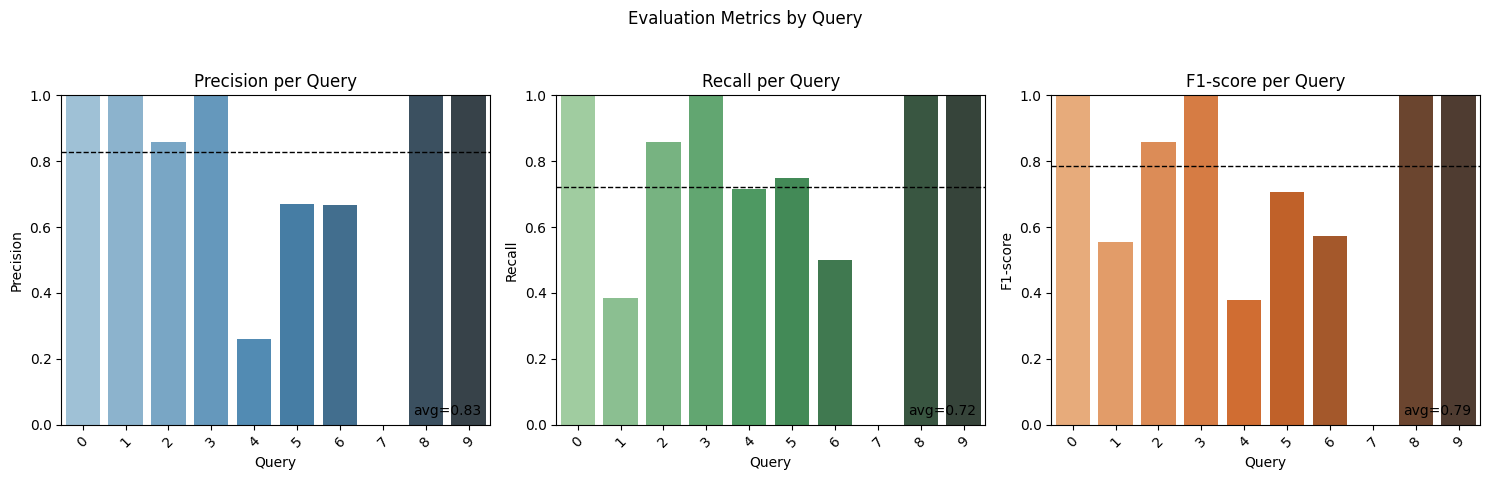

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
# Precision
sns.barplot(x=res_df.index, y=res_df["Prec"], ax=axes[0], palette="Blues_d")
axes[0].set_title("Precision per Query")
axes[0].set_xlabel("Query")
axes[0].set_ylabel("Precision")
axes[0].set_ylim(0, 1)
axes[0].axhline(res_df["Prec"].mean(), color="k", linestyle="--", linewidth=1)
axes[0].text(0.98, 0.02, f'avg={res_df["Prec"].mean():.2f}', va="bottom", ha="right", transform=axes[0].transAxes)
# Recall
sns.barplot(x=res_df.index, y=res_df["Rec"], ax=axes[1], palette="Greens_d")
axes[1].set_title("Recall per Query")
axes[1].set_xlabel("Query")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
axes[1].axhline(res_df["Rec"].mean(), color="k", linestyle="--", linewidth=1)
axes[1].text(0.98, 0.02, f'avg={res_df["Rec"].mean():.2f}', va="bottom", ha="right", transform=axes[1].transAxes)
# F1
sns.barplot(x=res_df.index, y=res_df["F1"], ax=axes[2], palette="Oranges_d")
axes[2].set_title("F1-score per Query")
axes[2].set_xlabel("Query")
axes[2].set_ylabel("F1-score")
axes[2].set_ylim(0, 1)
axes[2].axhline(res_df["F1"].mean(), color="k", linestyle="--", linewidth=1)
axes[2].text(0.98, 0.02, f'avg={res_df["F1"].mean():.2f}', va="bottom", ha="right", transform=axes[2].transAxes)
for ax in axes:
    ax.set_xticklabels([str(i) for i in res_df.index], rotation=45)
plt.suptitle("Evaluation Metrics by Query")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
from timeit import default_timer as timer

num_runs = 100
averages = []

for query in QUERIES : 
    average = 0 
    for i in range(num_runs) :
     
        start = timer()
        requete_dict = pretraiteur.treat_request(query["query"])
        res = engine.search(requete_dict)
        end = timer()
        average += end - start

    averages.append(average / num_runs)
    

/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/4112080152.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=queries, y=averages, ax=ax, palette="Purples_d")
/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_91100/4112080152.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(i) for i in queries], rotation=45)


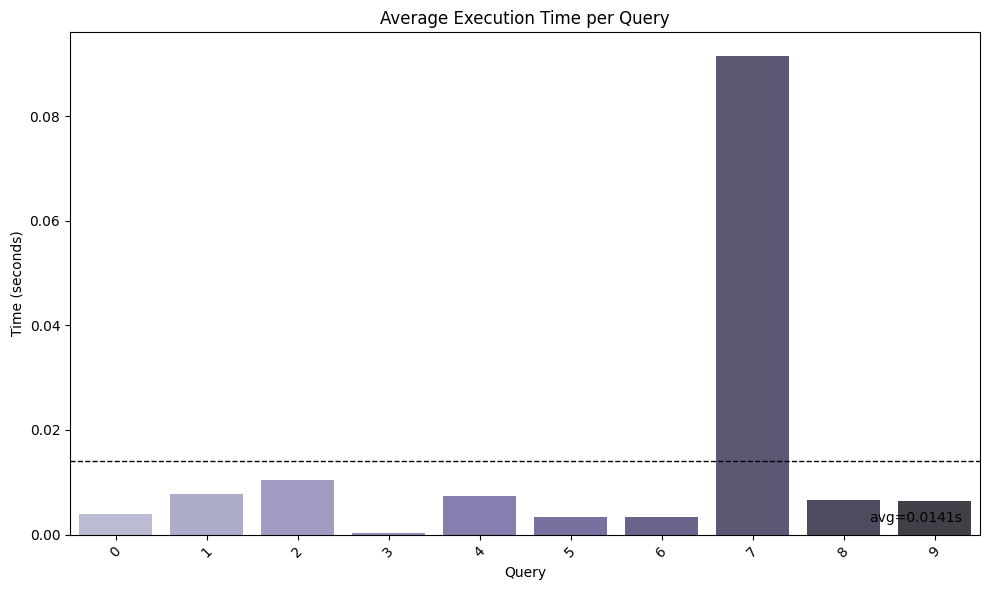

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
queries = list(range(0, len(averages)))
sns.barplot(x=queries, y=averages, ax=ax, palette="Purples_d")
ax.set_title("Average Execution Time per Query")
ax.set_xlabel("Query")
ax.set_ylabel("Time (seconds)")
ax.set_xticklabels([str(i) for i in queries], rotation=45)
ax.axhline(np.mean(averages), color="k", linestyle="--", linewidth=1)
ax.text(0.98, 0.02, f'avg={np.mean(averages):.4f}s', va="bottom", ha="right", transform=ax.transAxes)
plt.tight_layout()
plt.show()

In [9]:
from timeit import default_timer as timer

num_runs = 100
averages_pretreat = []
averages_search = []

for query in QUERIES : 
    average_search = 0
    average_pretreat = 0
    for i in range(num_runs) :
     
        start_p = timer()
        requete_dict = pretraiteur.treat_request(query["query"])
        end_p = timer()
        start_s = timer()
        res = engine.search(requete_dict)
        end_s = timer()
        average_pretreat += end_p - start_p
        average_search  += end_s - start_s

    averages_pretreat.append(average_pretreat / num_runs)
    averages_search.append(average_search / num_runs)
    

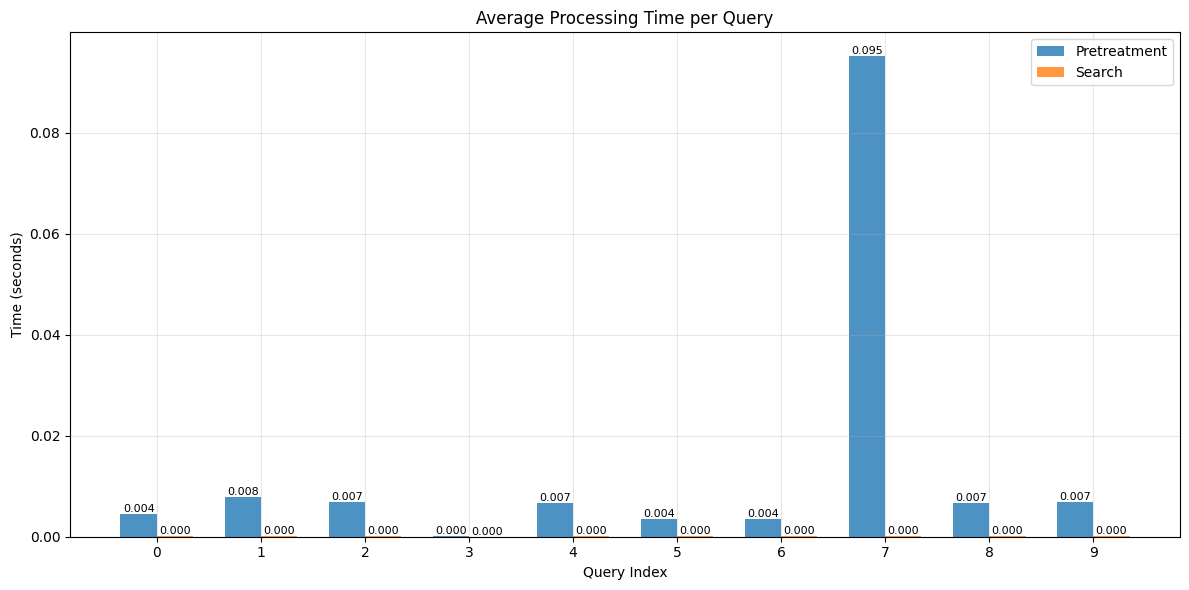

In [10]:
# Combined plot
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(averages_pretreat))
width = 0.35

bars1 = ax.bar(x - width/2, averages_pretreat, width, label='Pretreatment', alpha=0.8)
bars2 = ax.bar(x + width/2, averages_search, width, label='Search', alpha=0.8)

ax.set_xlabel('Query Index')
ax.set_ylabel('Time (seconds)')
ax.set_title('Average Processing Time per Query')
ax.set_xticks(x)
ax.legend()
ax.grid(True, alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

### Essayer de comprendre pourquoi le pretraitement de la requête 7 prend autant de temps

Query 1 ('qui parle de marcher'):
  Mean: 0.066198s
  Std:  0.022732s
  Min:  0.055123s
  Max:  0.208232s

Query 2 ('qui parle de supramoléculaire'):
  Mean: 0.003829s
  Std:  0.003777s
  Min:  0.002366s
  Max:  0.029742s

Difference: 0.062370s (1629.0% difference)


/var/folders/7q/d9s24s2135j03ltrsf6678640000gn/T/ipykernel_69902/3504569656.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([times_query1, times_query2], labels=['marcher', 'supramoléculaire'])


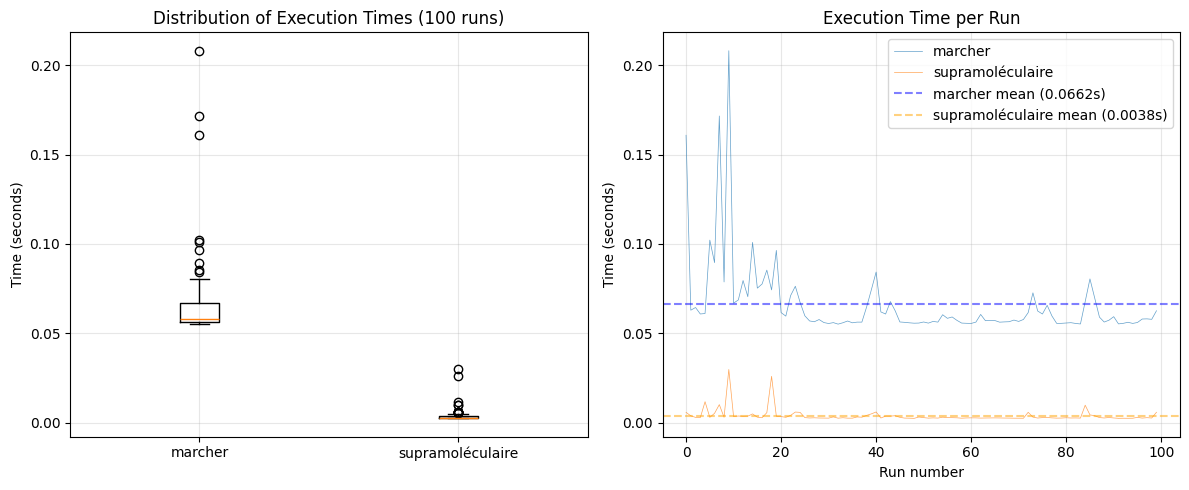

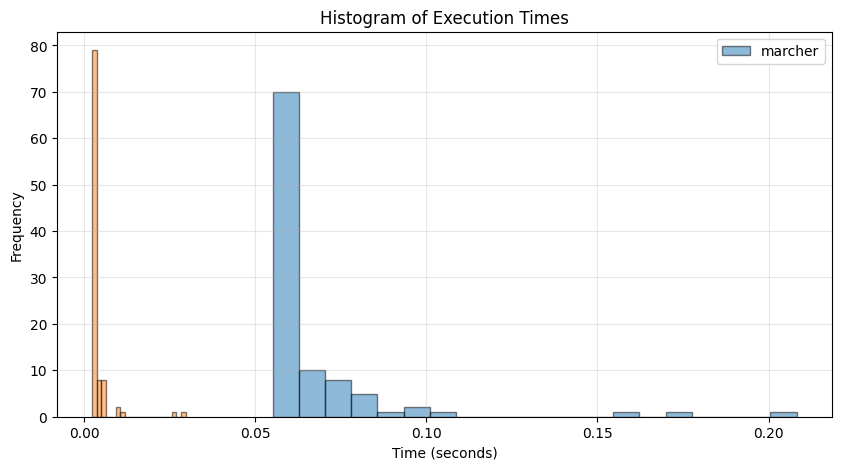

In [81]:
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import numpy as np

num_runs = 100
query1 = "qui parle de marcher"
query2 = "qui parle de supramoléculaire"


times_query1 = []
times_query2 = []

for i in range(num_runs):
    # Query 1
    s = timer()
    res = pretraiteur.extract_key_words(query1)
    e = timer()
    times_query1.append(e - s)
    
    # Query 2
    s = timer()
    res = pretraiteur.extract_key_words(query2)
    e = timer()
    times_query2.append(e - s)

# Calculate averages
avg_q1 = np.mean(times_query1)
avg_q2 = np.mean(times_query2)
std_q1 = np.std(times_query1)
std_q2 = np.std(times_query2)

# Print statistics
print(f"Query 1 ('{query1}'):")
print(f"  Mean: {avg_q1:.6f}s")
print(f"  Std:  {std_q1:.6f}s")
print(f"  Min:  {np.min(times_query1):.6f}s")
print(f"  Max:  {np.max(times_query1):.6f}s")
print()
print(f"Query 2 ('{query2}'):")
print(f"  Mean: {avg_q2:.6f}s")
print(f"  Std:  {std_q2:.6f}s")
print(f"  Min:  {np.min(times_query2):.6f}s")
print(f"  Max:  {np.max(times_query2):.6f}s")
print()
print(f"Difference: {abs(avg_q1 - avg_q2):.6f}s ({abs(avg_q1 - avg_q2)/min(avg_q1, avg_q2)*100:.1f}% difference)")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plots
axes[0].boxplot([times_query1, times_query2], labels=['marcher', 'supramoléculaire'])
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Distribution of Execution Times (100 runs)')
axes[0].grid(True, alpha=0.3)

# Line plot showing evolution over runs
axes[1].plot(times_query1, label='marcher', alpha=0.7, linewidth=0.5)
axes[1].plot(times_query2, label='supramoléculaire', alpha=0.7, linewidth=0.5)
axes[1].axhline(y=avg_q1, color='blue', linestyle='--', label=f'marcher mean ({avg_q1:.4f}s)', alpha=0.5)
axes[1].axhline(y=avg_q2, color='orange', linestyle='--', label=f'supramoléculaire mean ({avg_q2:.4f}s)', alpha=0.5)
axes[1].set_xlabel('Run number')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Execution Time per Run')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Histogram comparison
plt.figure(figsize=(10, 5))
plt.hist(times_query1, bins=20, alpha=0.5, label='marcher', edgecolor='black')
plt.hist(times_query2, bins=20, alpha=0.5, label='', edgecolor='black')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Execution Times')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [78]:
len(pretraiteur.keyword_extractor.correcteur._generate_candidates("marcher"))

3640

In [79]:
len(pretraiteur.keyword_extractor.correcteur._generate_candidates("supramoléculaire"))

909

In [74]:
lemma_df = pd.DataFrame({"lemmes" : pretraiteur.lemmas})
lemma_df["len"] = lemma_df["lemmes"].str.len()
lemma_df

,lemmes,len
0,microcircuit,12
1,doudin,6
2,supramoléculaire,16
3,sadron,6
4,giuseppone,10
...,...,...
11555,développer,10
11556,alors,5
11557,avoir,5
11558,faire,5


<Axes: xlabel='len', ylabel='Count'>

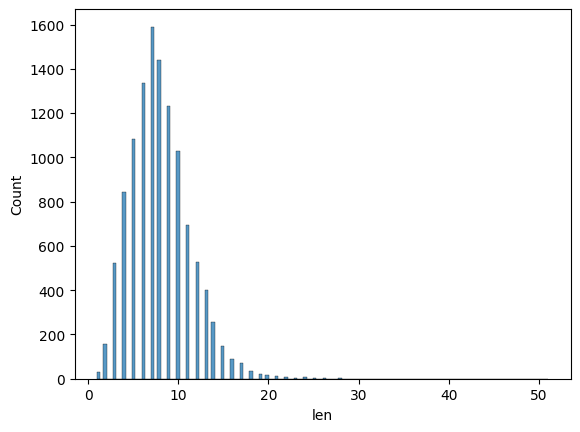

In [75]:
sns.histplot(lemma_df, x = 'len')